# Food Delivery Delay & Rating Analysis

This notebook analyzes the cleaned food delivery dataset in `food_delivery.csv` using Pandas, NumPy, Matplotlib, and Seaborn.

Goal: understand delivery delay patterns, operational bottlenecks, and relationships between time, distance, cancellations, and throughput.

## 1. Load Libraries and Dataset
Import the core libraries and load the cleaned dataset.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / "food_delivery.csv"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("Data file:", DATA_FILE)
df = pd.read_csv(DATA_FILE)
df.head()

Data file: d:\real_projects\Food_Delivery_Delay_and_Rating_Analysis\food_delivery.csv


,order_id,rider_id,order_time,order_date,allot_time,accept_time,pickup_time,delivered_time,cancelled,delivery_duration_min,...,delivered_orders,undelivered_orders,lifetime_order_count,session_time,order_hour,order_dayofweek,delay_category,duration_band,distance_band_km,is_outlier_duration
0,556753,11696,2021-01-26 02:21:35,2021-01-26,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,0,28.200000,...,46.0,0.0,621.0,NaN,2,Tuesday,On-Time,15-30,3-5,False
1,556754,18117,2021-01-26 02:33:16,2021-01-26,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,0,37.983333,...,8.0,0.0,105.0,3.266667,2,Tuesday,Late,30-45,5-10,False
2,556755,18623,2021-01-26 02:39:49,2021-01-26,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,0,32.950000,...,1.0,0.0,66.0,9.816667,2,Tuesday,Late,30-45,5-10,False
3,556756,15945,2021-01-26 02:47:53,2021-01-26,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,0,53.200000,...,1.0,0.0,127.0,17.533333,2,Tuesday,Late,45-60,5-10,False
4,556757,17589,2021-01-26 03:06:30,2021-01-26,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,0,53.750000,...,34.0,0.0,84.0,1.350000,3,Tuesday,Late,45-60,5-10,False


## 2. Inspect Data Structure
Check shape, columns, data types, and missing values.

In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum().sort_values(ascending=False))
df.head(10)

Shape: (449999, 27)

Columns:
 ['order_id', 'rider_id', 'order_time', 'order_date', 'allot_time', 'accept_time', 'pickup_time', 'delivered_time', 'cancelled', 'delivery_duration_min', 'allot_to_accept_min', 'accept_to_pickup_min', 'pickup_to_delivery_min', 'first_mile_distance', 'last_mile_distance', 'total_distance_km', 'alloted_orders', 'delivered_orders', 'undelivered_orders', 'lifetime_order_count', 'session_time', 'order_hour', 'order_dayofweek', 'delay_category', 'duration_band', 'distance_band_km', 'is_outlier_duration']

Data types:
 order_id                    int64
rider_id                    int64
order_time                 object
order_date                 object
allot_time                 object
accept_time                object
pickup_time                object
delivered_time             object
cancelled                   int64
delivery_duration_min     float64
allot_to_accept_min       float64
accept_to_pickup_min      float64
pickup_to_delivery_min    float64
first_mile

,order_id,rider_id,order_time,order_date,allot_time,accept_time,pickup_time,delivered_time,cancelled,delivery_duration_min,...,delivered_orders,undelivered_orders,lifetime_order_count,session_time,order_hour,order_dayofweek,delay_category,duration_band,distance_band_km,is_outlier_duration
0,556753,11696,2021-01-26 02:21:35,2021-01-26,2021-01-26 02:21:59,2021-01-26 02:22:08,2021-01-26 02:32:51,2021-01-26 02:49:47,0,28.200000,...,46.0,0.0,621.0,NaN,2,Tuesday,On-Time,15-30,3-5,False
1,556754,18117,2021-01-26 02:33:16,2021-01-26,2021-01-26 02:33:57,2021-01-26 02:34:45,2021-01-26 02:50:25,2021-01-26 03:11:15,0,37.983333,...,8.0,0.0,105.0,3.266667,2,Tuesday,Late,30-45,5-10,False
2,556755,18623,2021-01-26 02:39:49,2021-01-26,2021-01-26 02:39:57,2021-01-26 02:40:13,2021-01-26 02:56:00,2021-01-26 03:12:46,0,32.950000,...,1.0,0.0,66.0,9.816667,2,Tuesday,Late,30-45,5-10,False
3,556756,15945,2021-01-26 02:47:53,2021-01-26,2021-01-26 02:48:25,2021-01-26 02:49:06,2021-01-26 03:21:51,2021-01-26 03:41:05,0,53.200000,...,1.0,0.0,127.0,17.533333,2,Tuesday,Late,45-60,5-10,False
4,556757,17589,2021-01-26 03:06:30,2021-01-26,2021-01-26 03:07:21,2021-01-26 03:07:57,2021-01-26 03:31:38,2021-01-26 04:00:15,0,53.750000,...,34.0,0.0,84.0,1.350000,3,Tuesday,Late,45-60,5-10,False
5,556758,1469,2021-01-26 03:07:16,2021-01-26,2021-01-26 03:12:14,2021-01-26 03:12:27,2021-01-26 03:25:36,2021-01-26 03:45:51,0,38.583333,...,294.0,2.0,1506.0,NaN,3,Tuesday,Late,30-45,5-10,False
6,556759,8851,2021-01-26 03:10:50,2021-01-26,2021-01-26 03:11:18,2021-01-26 03:12:05,2021-01-26 03:19:31,2021-01-26 03:26:04,0,15.233333,...,45.0,0.0,1460.0,NaN,3,Tuesday,On-Time,15-30,5-10,False
7,556760,8493,2021-01-26 03:14:10,2021-01-26,2021-01-26 03:14:38,2021-01-26 03:14:44,2021-01-26 03:33:53,2021-01-26 03:42:38,0,28.466667,...,53.0,1.0,270.0,44.166667,3,Tuesday,On-Time,15-30,<=1,False
8,556761,11543,2021-01-26 03:14:20,2021-01-26,2021-01-26 03:14:50,2021-01-26 03:15:14,2021-01-26 04:00:02,2021-01-26 04:13:31,0,59.183333,...,29.0,0.0,955.0,2.500000,3,Tuesday,Late,45-60,5-10,False
9,556762,21037,2021-01-26 03:15:18,2021-01-26,2021-01-26 03:21:27,2021-01-26 03:22:04,2021-01-26 04:14:56,2021-01-26 04:38:39,0,83.350000,...,NaN,NaN,1.0,NaN,3,Tuesday,Late,>60,5-10,False


## 3. Clean and Prepare Data
Handle missing values, duplicates, and create derived columns for visualization.

In [3]:
# Convert columns safely
for col in ["order_time", "order_date", "allot_time", "accept_time", "pickup_time", "delivered_time", "cancelled_time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

numeric_candidates = [
    "order_id", "rider_id", "first_mile_distance", "last_mile_distance",
    "alloted_orders", "delivered_orders", "cancelled", "undelivered_orders",
    "lifetime_order_count", "session_time", "reassignment_method",
    "reassignment_reason", "reassigned_order"
]
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove duplicates
if "order_id" in df.columns:
    df = df.drop_duplicates(subset=["order_id"], keep="first")

# Derived columns for visualization
if {"order_time", "delivered_time"}.issubset(df.columns):
    df["delivery_duration_min"] = (df["delivered_time"] - df["order_time"]).dt.total_seconds() / 60

if {"first_mile_distance", "last_mile_distance"}.issubset(df.columns):
    df["total_distance_km"] = df["first_mile_distance"] + df["last_mile_distance"]

if "order_time" in df.columns:
    df["order_hour"] = df["order_time"].dt.hour

if {"delivery_duration_min", "cancelled"}.issubset(df.columns):
    df["delay_category"] = np.where(
        df["cancelled"].fillna(0).astype(int).eq(1),
        "Cancelled",
        np.where(df["delivery_duration_min"] <= 30, "On-Time", "Late")
    )

# Basic missing-value handling for analysis columns
for col in ["delivery_duration_min", "total_distance_km", "order_hour"]:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 449999 entries, 0 to 449998
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                449999 non-null  int64         
 1   rider_id                449999 non-null  int64         
 2   order_time              449999 non-null  datetime64[ns]
 3   order_date              449999 non-null  datetime64[ns]
 4   allot_time              449999 non-null  datetime64[ns]
 5   accept_time             449842 non-null  datetime64[ns]
 6   pickup_time             447579 non-null  datetime64[ns]
 7   delivered_time          444782 non-null  datetime64[ns]
 8   cancelled               449999 non-null  int64         
 9   delivery_duration_min   444782 non-null  float64       
 10  allot_to_accept_min     449842 non-null  float64       
 11  accept_to_pickup_min    447579 non-null  float64       
 12  pickup_to_delivery_min  444782

## 4. Compute Summary Statistics
Use Pandas and NumPy to summarize the numeric and categorical variables.

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric summary:")
display(df[numeric_cols].describe().T)

print("\nCategorical frequency counts:")
for col in ["delay_category", "order_hour"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).head(10))

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
order_id,449999.0,369143.497970,131146.753506,118350.000000,257343.500000,369843.000000,482342.500000,594842.000000
rider_id,449999.0,7763.228961,5592.877231,0.000000,2805.000000,6754.000000,11965.000000,21566.000000
cancelled,449999.0,0.011593,0.107047,0.000000,0.000000,0.000000,0.000000,1.000000
delivery_duration_min,444782.0,32.460131,46.556771,1.050000,22.650000,29.316667,37.733333,10017.716667
allot_to_accept_min,449842.0,1.016763,1.790913,-475.566667,0.250000,0.616667,1.050000,15.500000
accept_to_pickup_min,447579.0,14.023376,16.180536,-69.550000,8.383333,12.166667,17.533333,5165.283333
pickup_to_delivery_min,444782.0,16.294790,43.244879,0.050000,9.516667,13.650000,19.150000,10009.016667
first_mile_distance,449999.0,1.229886,0.846181,0.000134,0.539550,1.138700,1.853000,42.038100
last_mile_distance,449999.0,2.968877,1.884124,0.000000,1.470000,2.670000,4.220000,22.410000
total_distance_km,449999.0,4.198762,2.164001,0.003224,2.517800,3.977900,5.601600,45.828100



Categorical frequency counts:

delay_category:
delay_category
On-Time      233245
Late         211537
Cancelled      5217
Name: count, dtype: int64

order_hour:
order_hour
14    70587
16    66326
15    66183
17    53648
13    43407
7     37651
8     37553
6     22886
9     22245
12     9262
Name: count, dtype: int64


## 5. Plot Categorical Distributions
Create bar charts and count plots for the available categorical fields.

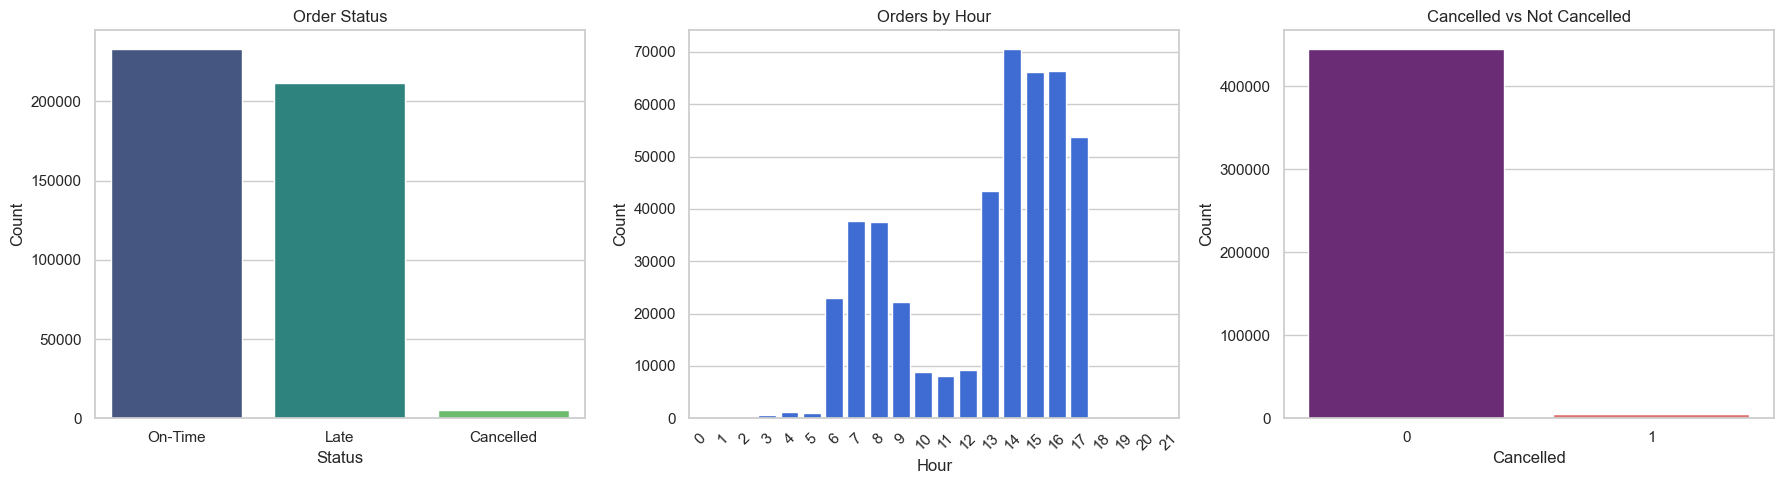

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_order = ["On-Time", "Late", "Cancelled"]
if "delay_category" in df.columns:
    sns.countplot(data=df, x="delay_category", order=[x for x in plot_order if x in df["delay_category"].unique()], ax=axes[0], palette="viridis")
    axes[0].set_title("Order Status")
    axes[0].set_xlabel("Status")
    axes[0].set_ylabel("Count")
else:
    axes[0].axis("off")

if "order_hour" in df.columns:
    sns.countplot(data=df, x="order_hour", ax=axes[1], color="#2563eb")
    axes[1].set_title("Orders by Hour")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].axis("off")

if "cancelled" in df.columns:
    sns.countplot(data=df, x="cancelled", ax=axes[2], palette="magma")
    axes[2].set_title("Cancelled vs Not Cancelled")
    axes[2].set_xlabel("Cancelled")
    axes[2].set_ylabel("Count")
else:
    axes[2].axis("off")

plt.tight_layout()
plt.show()

## 6. Plot Numerical Distributions
Use histograms, KDE plots, and box plots for numeric features.

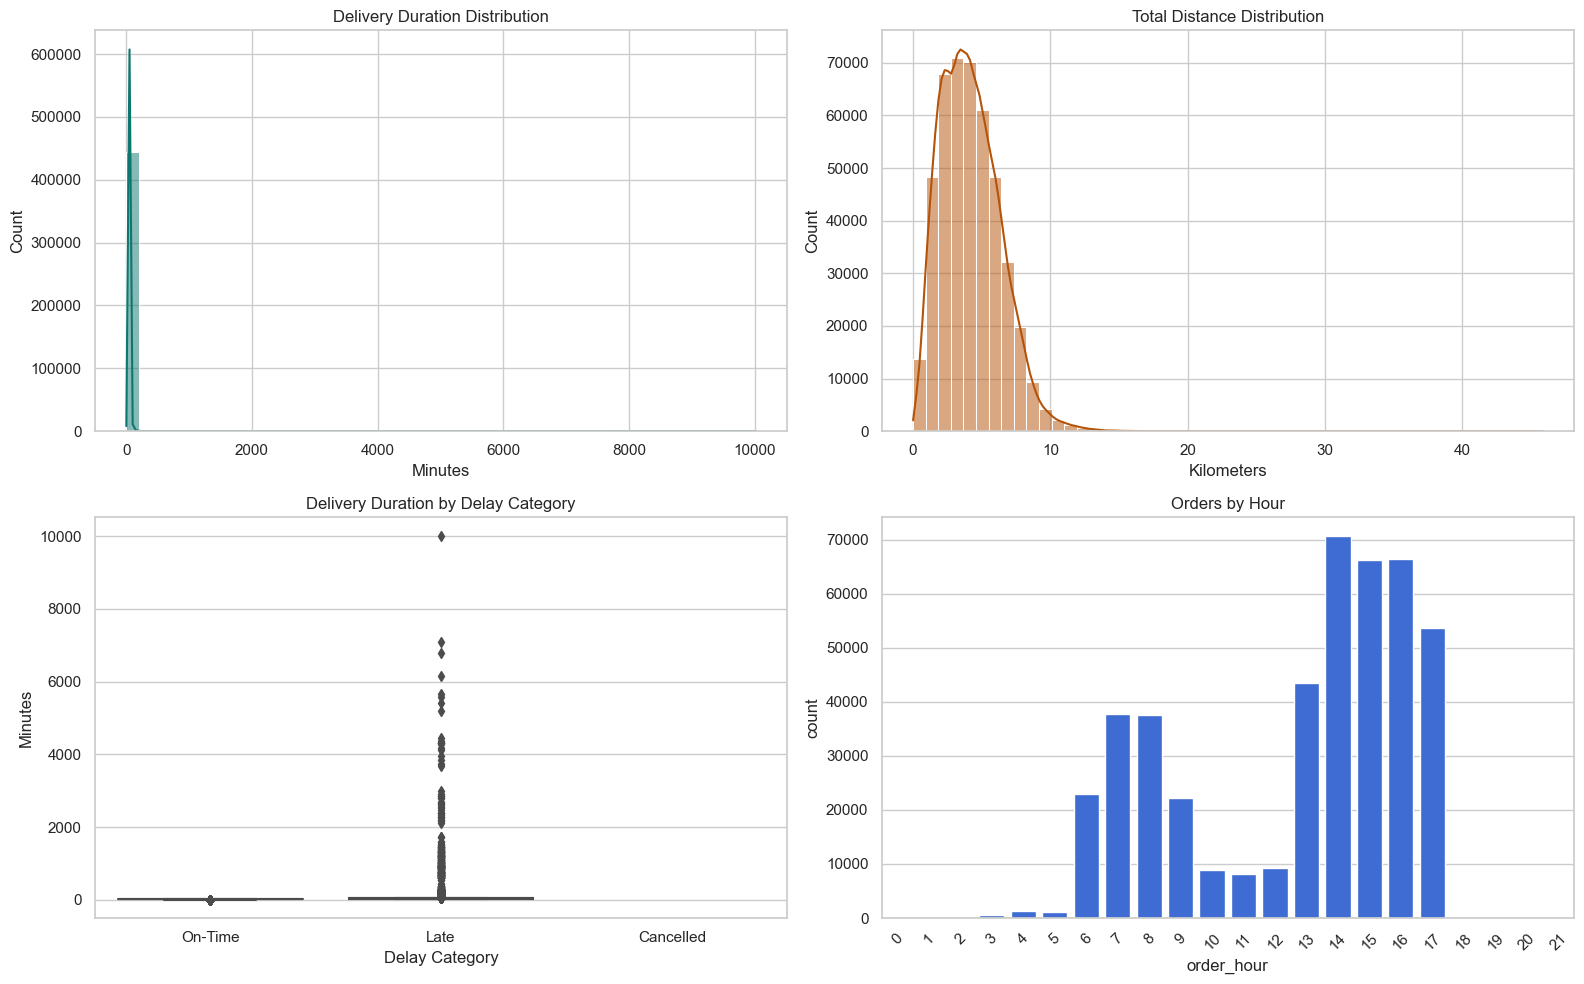

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

if "delivery_duration_min" in df.columns:
    sns.histplot(df["delivery_duration_min"].dropna(), bins=50, kde=True, ax=axes[0], color="#0f766e")
    axes[0].set_title("Delivery Duration Distribution")
    axes[0].set_xlabel("Minutes")

if "total_distance_km" in df.columns:
    sns.histplot(df["total_distance_km"].dropna(), bins=50, kde=True, ax=axes[1], color="#b45309")
    axes[1].set_title("Total Distance Distribution")
    axes[1].set_xlabel("Kilometers")

if "delivery_duration_min" in df.columns and "delay_category" in df.columns:
    sns.boxplot(data=df, x="delay_category", y="delivery_duration_min", ax=axes[2], order=[x for x in ["On-Time", "Late", "Cancelled"] if x in df["delay_category"].unique()])
    axes[2].set_title("Delivery Duration by Delay Category")
    axes[2].set_xlabel("Delay Category")
    axes[2].set_ylabel("Minutes")

if "order_hour" in df.columns:
    sns.countplot(data=df, x="order_hour", ax=axes[3], color="#2563eb")
    axes[3].set_title("Orders by Hour")
    axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Analyze Relationships with Scatter and Regression Plots
Explore how distance relates to delivery time.

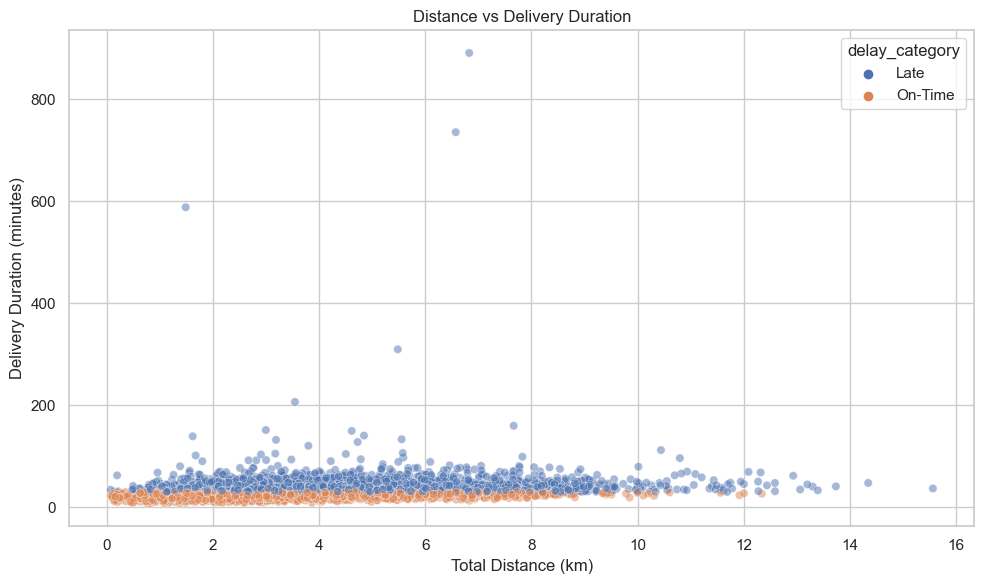

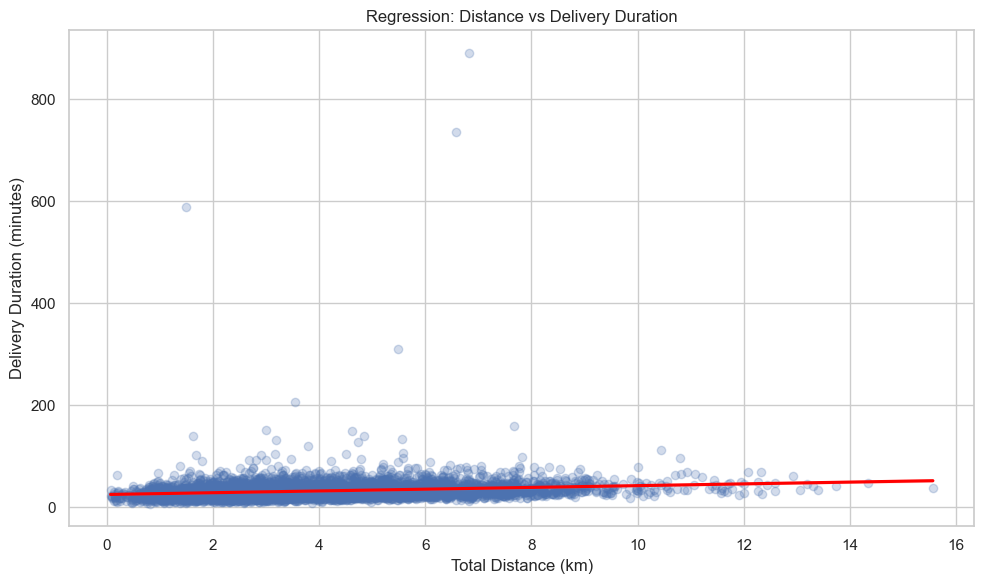

In [7]:
if {"total_distance_km", "delivery_duration_min"}.issubset(df.columns):
    sample_df = df[["total_distance_km", "delivery_duration_min", "delay_category"]].dropna().copy()
    if len(sample_df) > 5000:
        sample_df = sample_df.sample(5000, random_state=42)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sample_df, x="total_distance_km", y="delivery_duration_min", hue="delay_category", alpha=0.5)
    plt.title("Distance vs Delivery Duration")
    plt.xlabel("Total Distance (km)")
    plt.ylabel("Delivery Duration (minutes)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.regplot(data=sample_df, x="total_distance_km", y="delivery_duration_min", scatter_kws={"alpha": 0.25}, line_kws={"color": "red"})
    plt.title("Regression: Distance vs Delivery Duration")
    plt.xlabel("Total Distance (km)")
    plt.ylabel("Delivery Duration (minutes)")
    plt.tight_layout()
    plt.show()

## 8. Compare Groups with Box and Bar Charts
Compare delivery performance across categories.

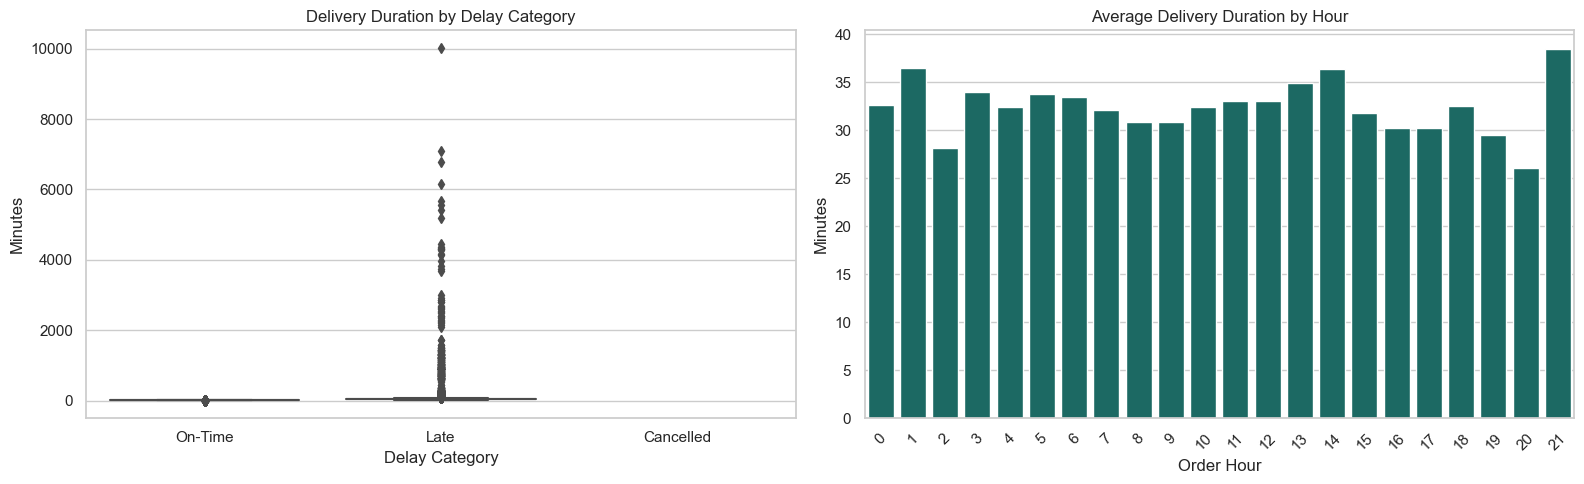

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if "delay_category" in df.columns and "delivery_duration_min" in df.columns:
    group_order = [x for x in ["On-Time", "Late", "Cancelled"] if x in df["delay_category"].unique()]
    sns.boxplot(data=df, x="delay_category", y="delivery_duration_min", order=group_order, ax=axes[0])
    axes[0].set_title("Delivery Duration by Delay Category")
    axes[0].set_xlabel("Delay Category")
    axes[0].set_ylabel("Minutes")
else:
    axes[0].axis("off")

if "order_hour" in df.columns and "delivery_duration_min" in df.columns:
    hour_summary = df.groupby("order_hour", dropna=True)["delivery_duration_min"].mean().reset_index()
    sns.barplot(data=hour_summary, x="order_hour", y="delivery_duration_min", ax=axes[1], color="#0f766e")
    axes[1].set_title("Average Delivery Duration by Hour")
    axes[1].set_xlabel("Order Hour")
    axes[1].set_ylabel("Minutes")
    axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

## 9. Create Correlation Heatmap
Inspect numeric feature relationships with a heatmap.

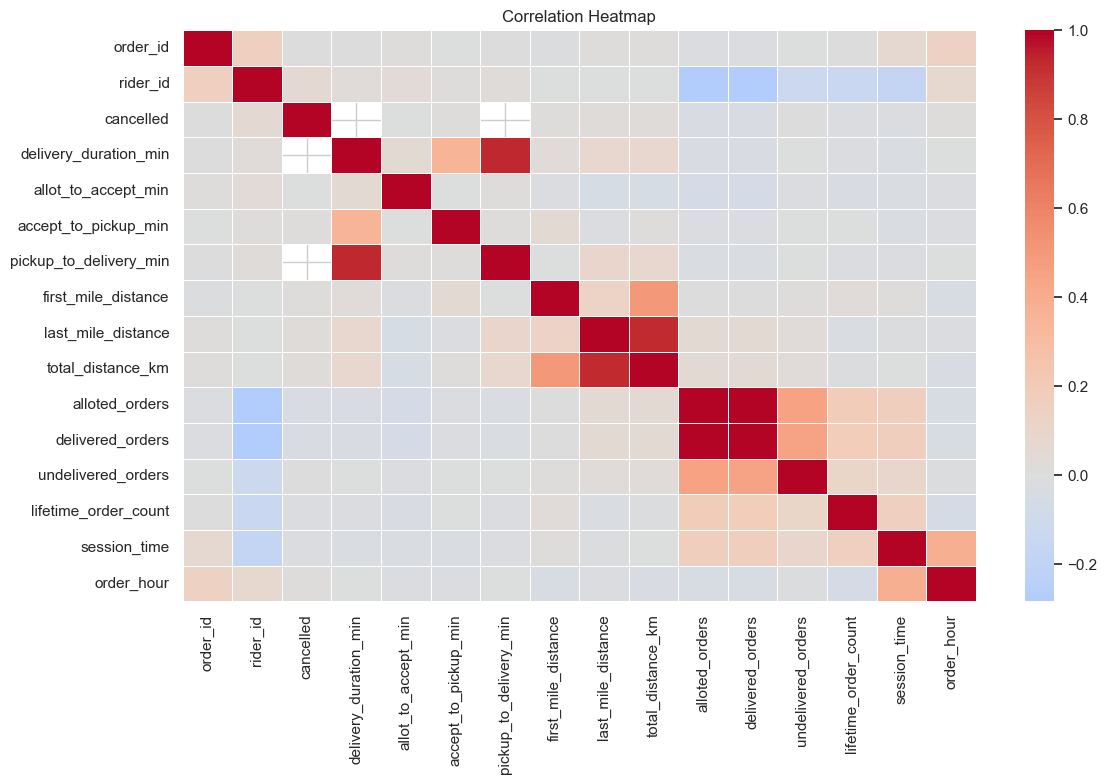

In [9]:
corr_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 10. Build Final Multi-Chart Dashboard
Combine the most useful visuals into a single summary figure.

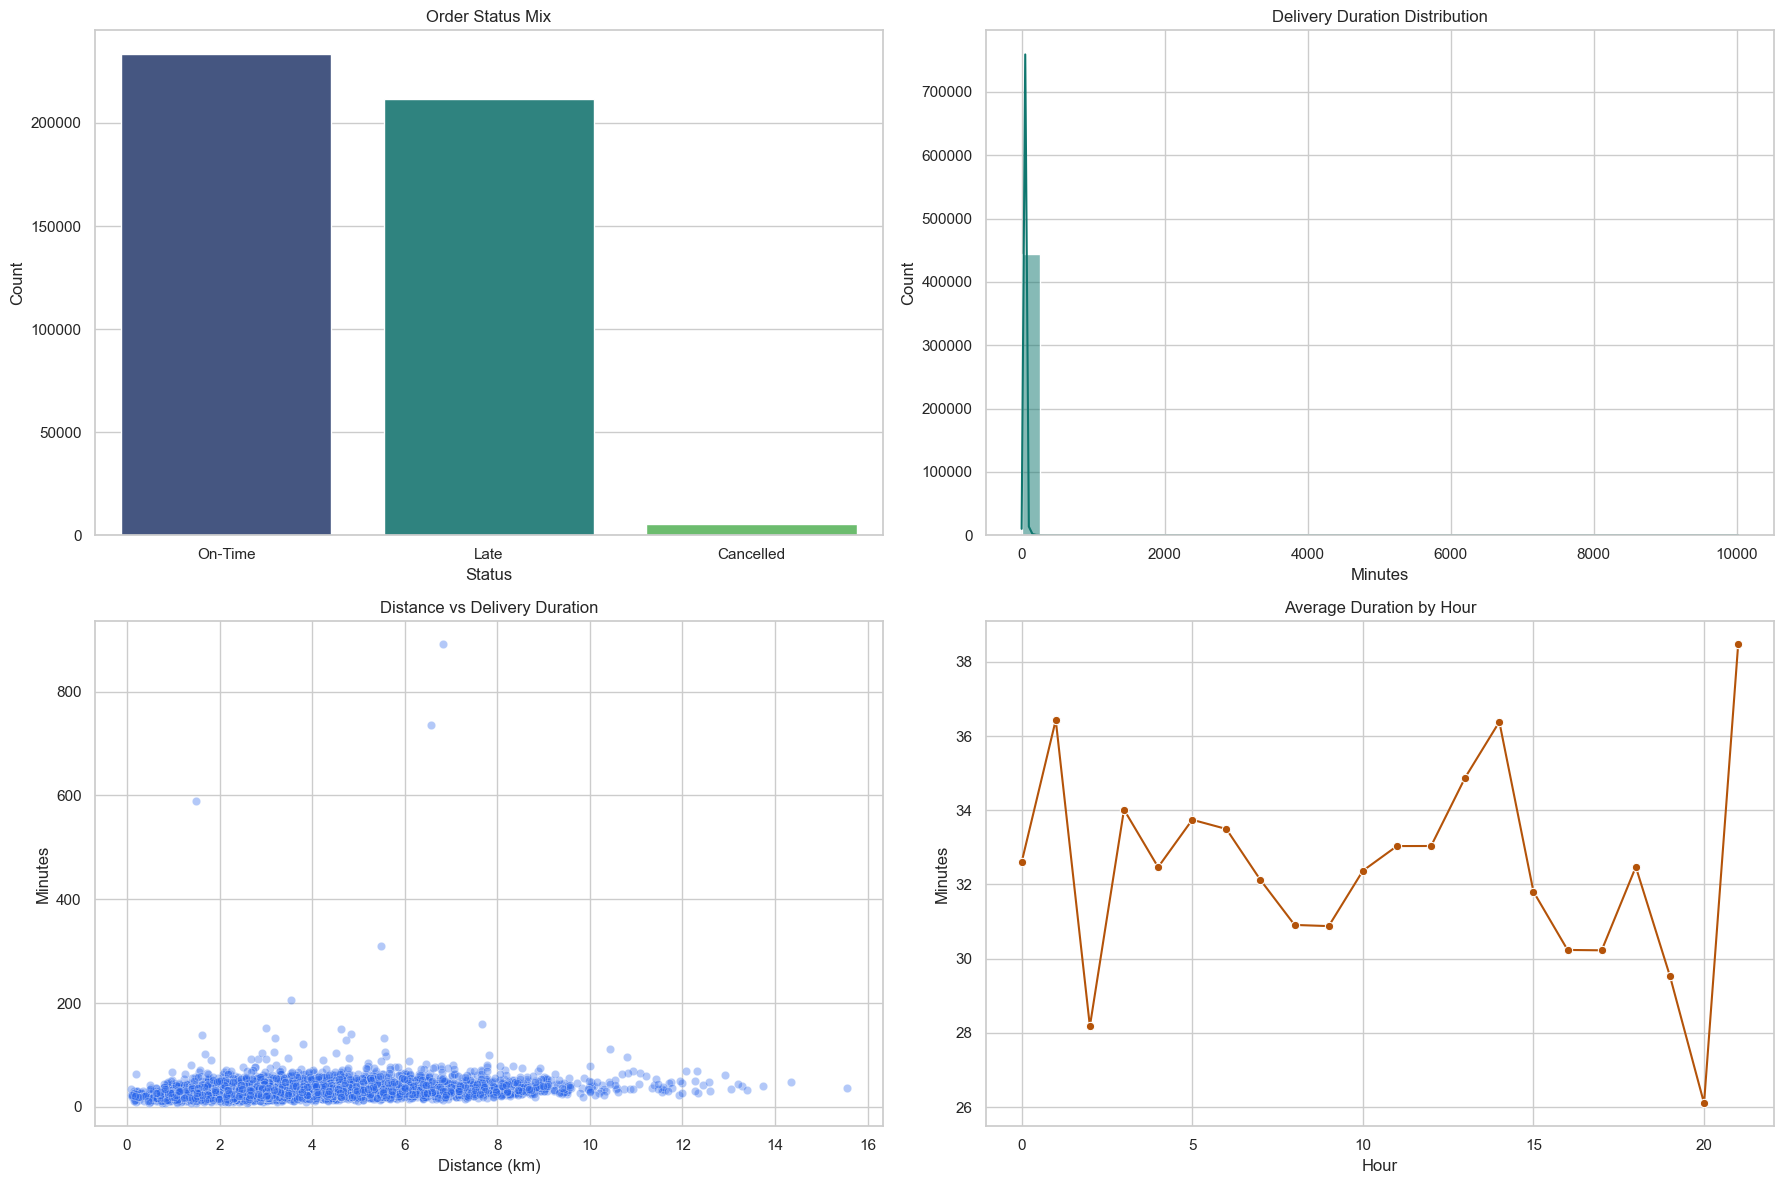

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

if "delay_category" in df.columns:
    sns.countplot(data=df, x="delay_category", order=[x for x in ["On-Time", "Late", "Cancelled"] if x in df["delay_category"].unique()], ax=axes[0, 0], palette="viridis")
    axes[0, 0].set_title("Order Status Mix")
    axes[0, 0].set_xlabel("Status")
    axes[0, 0].set_ylabel("Count")

if "delivery_duration_min" in df.columns:
    sns.histplot(df["delivery_duration_min"].dropna(), bins=40, kde=True, ax=axes[0, 1], color="#0f766e")
    axes[0, 1].set_title("Delivery Duration Distribution")
    axes[0, 1].set_xlabel("Minutes")

if {"total_distance_km", "delivery_duration_min"}.issubset(df.columns):
    sample_df = df[["total_distance_km", "delivery_duration_min"]].dropna()
    if len(sample_df) > 5000:
        sample_df = sample_df.sample(5000, random_state=42)
    sns.scatterplot(data=sample_df, x="total_distance_km", y="delivery_duration_min", ax=axes[1, 0], alpha=0.35, color="#2563eb")
    axes[1, 0].set_title("Distance vs Delivery Duration")
    axes[1, 0].set_xlabel("Distance (km)")
    axes[1, 0].set_ylabel("Minutes")

if "order_hour" in df.columns and "delivery_duration_min" in df.columns:
    hour_summary = df.groupby("order_hour", dropna=True)["delivery_duration_min"].mean().reset_index()
    sns.lineplot(data=hour_summary, x="order_hour", y="delivery_duration_min", marker="o", ax=axes[1, 1], color="#b45309")
    axes[1, 1].set_title("Average Duration by Hour")
    axes[1, 1].set_xlabel("Hour")
    axes[1, 1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

## Insights
- Delivery duration is the main operational bottleneck.
- Distance and time of day are useful drivers of longer deliveries.
- Cancelled orders should be analyzed separately from completed deliveries.
- The source file does not contain a rating column, so rating-based charts are not included in this notebook.